<div align="center">

# 🩺 Patient Segmentation using Unsupervised Machine Learning
### A Clustering-Based Analysis of the NHANES Health & Nutrition Survey

---

**Master's Level Machine Learning — Mini Project**

</div>

| | |
|---|---|
| **Project Title** | Patient Segmentation using Unsupervised Machine Learning on NHANES Data |
| **Student Name** | Syed Khaja Irfan Uddin |
| **University** | PES University |
| **Course** | Unsupervised Machine Learning / Machine Learning (Master's) |
| **Project Objective** | Discover clinically meaningful patient sub-populations ("segments") from demographic, dietary, and laboratory data using clustering algorithms, and translate them into actionable healthcare insights. |
| **Dataset** | National Health and Nutrition Examination Survey (NHANES), NCHS / CDC |
| **Software Used** | Python 3, Jupyter Notebook |
| **Primary Metric** | Silhouette Score |
| **Dimensionality Rule** | Any dimensionality reduction must retain **≥ 95%** of variance |

---

#### Python Libraries Used
`numpy` · `pandas` · `matplotlib` · `seaborn` · `plotly` · `scikit-learn` · `scipy` · `yellowbrick` · `kneed` *(and optionally `umap-learn`)*

<div align="center">
<i>"Not all patients are the same — and treating them as if they were is the central failure of population-scale medicine.<br>Clustering lets the data tell us who belongs together."</i>
</div>

# 1 · Introduction

## 1.1 What is Machine Learning?

**Machine Learning (ML)** is the branch of Artificial Intelligence in which algorithms *learn patterns directly from data* instead of being explicitly programmed with hand-written rules. Formally (Tom Mitchell, 1997):

> A computer program is said to learn from experience **E** with respect to some task **T** and performance measure **P**, if its performance at **T**, as measured by **P**, improves with experience **E**.

In this project:
- **Task (T)** → grouping patients into health segments,
- **Experience (E)** → the NHANES survey records,
- **Performance (P)** → the **Silhouette Score** (cohesion vs. separation of clusters).

## 1.2 Types of Machine Learning

| Paradigm | Labels? | Goal | Example |
|---|---|---|---|
| **Supervised** | Yes (X → y) | Predict a known target | Predict diabetes (yes/no) |
| **Unsupervised** | No (X only) | Discover hidden structure | **Segment patients (this project)** |
| **Semi-supervised** | Few labels | Leverage a little labelled data | Label a few scans, propagate |
| **Reinforcement** | Reward signal | Learn a policy by trial & error | Adaptive treatment dosing |

### Supervised Learning
The model sees input–output pairs $(x_i, y_i)$ and learns a mapping $f: X \rightarrow y$ that minimises a loss $\mathcal{L}(y, f(x))$. Requires a **ground-truth label**.

### Unsupervised Learning
The model sees **only inputs** $\{x_1, x_2, \dots, x_n\}$ with **no labels**, and must uncover the intrinsic geometry of the data — density, groupings, manifolds. **Clustering** is the flagship unsupervised task, and the heart of this project. Because NHANES has *no "patient type" column*, patient segmentation is inherently unsupervised.

## 1.3 Clustering

**Clustering** partitions $n$ observations into $k$ groups so that points within a group are *similar* and points in different groups are *dissimilar*. "Similarity" is quantified by a **distance metric** — most commonly the Euclidean distance:

$$ d(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{j=1}^{p} (x_j - y_j)^2} $$

A "good" clustering minimises **intra-cluster** distance and maximises **inter-cluster** distance.

### Why clustering is important
- Reveals structure **without labels** — ideal when outcomes are unknown or expensive to obtain.
- Compresses a complex population into a handful of interpretable **archetypes**.
- Serves as a foundation for downstream personalisation, anomaly detection, and resource planning.

## 1.4 Real-World Applications
Customer/market segmentation · document & image grouping · fraud & anomaly detection · gene-expression subtyping · recommendation systems · **and healthcare patient stratification**.

## 1.5 Healthcare Analytics & Patient Segmentation

- **Healthcare analytics** turns raw clinical, dietary, and lab data into decisions that improve outcomes and lower cost.
- **Patient segmentation** groups patients by shared health profiles (metabolic, cardiovascular, nutritional). Unlike one-size-fits-all care, segments enable *targeted* action.
- **Precision medicine** — "the right treatment, for the right patient, at the right time." Segments are the population-level scaffold on which precision medicine is built.
- **Population health management** — payers and public-health bodies allocate scarce resources (screening, clinics, budgets) to the segments that need them most.
- **Preventive healthcare** — identifying *rising-risk* segments (e.g. pre-diabetic, dyslipidemic) enables intervention *before* disease onset, where impact is highest and cost is lowest.

## 1.6 Expected Outcome of this Project
A set of **data-driven, clinically interpretable patient segments** (e.g. *Healthy Young Adults*, *Metabolic-Risk*, *High-Cardiovascular-Risk Seniors*), each with a quantitative profile and a set of recommended healthcare interventions — validated by the **Silhouette Score** and stress-tested across multiple clustering algorithms.

## 1.7 Environment Setup & Global Configuration

**What we are doing:** importing every library, fixing a global random seed for reproducibility, and configuring a consistent, publication-quality visual style.

**Why it is required:** A fixed `RANDOM_STATE` guarantees that stochastic steps (K-Means initialisation, sampling, t-SNE) produce identical results on every run — a non-negotiable requirement for academic reproducibility. Centralised styling ensures every figure shares fonts, sizes, and a colour palette.

In [1]:
# ============================== CORE STACK ==============================
import os                     # file-system paths
import time                   # execution timing (used in the Appendix)
import warnings               # silence non-critical library warnings
import numpy as np            # numerical arrays / linear algebra
import pandas as pd           # tabular data handling

# ============================== VISUALISATION ===========================
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# ============================== SCIKIT-LEARN ============================
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.cluster import (KMeans, DBSCAN, AgglomerativeClustering,
                             SpectralClustering)
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             davies_bouldin_score, calinski_harabasz_score)
from sklearn.manifold import TSNE

# ============================== SCIPY / STATS ===========================
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

warnings.filterwarnings('ignore')          # keep the notebook output clean

# ---- Global reproducibility seed ----
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ---- Publication-quality plotting defaults ----
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.figsize'  : (10, 5),   # default canvas size
    'figure.dpi'      : 110,       # crisp on screen
    'axes.titlesize'  : 13,
    'axes.titleweight': 'bold',
    'axes.labelsize'  : 11,
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
    'font.family'     : 'DejaVu Sans',
})
# A consistent qualitative palette reused for cluster colours throughout.
PALETTE = ['#2E86AB', '#E4572E', '#17A398', '#F4A261',
           '#8367C7', '#5C946E', '#D7263D', '#3D5A80']
sns.set_palette(PALETTE)
pio.templates.default = 'plotly_white'

# ---- Project directory ----

ROOT      = os.path.abspath('..')
DATA_DIR  = os.path.join(ROOT, 'data')
IMG_DIR   = os.path.join(ROOT, 'images')
MODEL_DIR = os.path.join(ROOT, 'models')
LOG_DIR   = os.path.join(ROOT, 'logs')
for _d in (DATA_DIR, IMG_DIR, MODEL_DIR, LOG_DIR):
    os.makedirs(_d, exist_ok=True)

# ---- Logging: write run logs to logs/ (and echo to the notebook) ----
import logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    handlers=[logging.FileHandler(os.path.join(LOG_DIR, 'run.log'), mode='w'),
              logging.StreamHandler()])
log = logging.getLogger('patient_segmentation')

# ---- Auto-save EVERY matplotlib figure to images/ (transparently) ----

_FIGN = {'n': 0}
_orig_show = plt.show
def _show_and_save(*args, **kwargs):
    _FIGN['n'] += 1
    try:
        fig = plt.gcf()
        fig.savefig(os.path.join(IMG_DIR, f'fig_{_FIGN["n"]:02d}.png'),
                    dpi=120, bbox_inches='tight')
    except Exception as _e:
        log.warning(f'figure save skipped: {_e}')
    return _orig_show(*args, **kwargs)
plt.show = _show_and_save

NB_START = time.time()          

log.info('Environment initialised | seed=%d', RANDOM_STATE)
print('Libraries imported successfully.')
print(f'pandas {pd.__version__} | numpy {np.__version__}')
print(f'Global RANDOM_STATE = {RANDOM_STATE}')
print(f'Project root : {ROOT}')
print(f'Figures -> images/ | models -> models/ | logs -> logs/run.log')

2026-07-21 14:45:31,574 | INFO | Environment initialised | seed=42


Libraries imported successfully.
pandas 2.3.3 | numpy 2.0.2
Global RANDOM_STATE = 42
Project root : /Users/syedirfanuddin/Documents/PES/Projects/UMLRS/Patient_segmentation
Figures -> images/ | models -> models/ | logs -> logs/run.log


# 2 · Dataset Understanding

## 2.1 What is NHANES?

The **National Health and Nutrition Examination Survey (NHANES)** is a flagship program of the **National Center for Health Statistics (NCHS)**, part of the **U.S. Centers for Disease Control and Prevention (CDC)**. It is unique in combining **in-person interviews**, **standardised physical/dietary examinations**, and **laboratory blood/urine assays** on a nationally representative sample of the U.S. civilian population.

- **Source:** <https://wwwn.cdc.gov/Nchs/Nhanes/>
- **Survey cycle in this file:** 2013–2014 (`DEMO_H`, `DR1TOT_H`, and the `*_H` laboratory files)
- **Sampling design:** complex, multi-stage, stratified probability sampling (hence the survey-weight columns `WTINT2YR`, `WTMEC2YR`, …).

## 2.2 Feature Categories

The project brief specifies three parameter families. NHANES organises variables by **Component**, which map directly onto them:

| Category | NHANES Component | Prefix(es) | Examples |
|---|---|---|---|
| **Demographic** | Demographics | `RI…`, `DM…`, `IND…` | age, gender, race, education, income-to-poverty ratio |
| **Dietary** | Dietary (24-hr recall, Day 1) | `DR1…` | energy (kcal), protein, carbs, sugar, fibre, fat, sodium |
| **Laboratory / Clinical** | Standard Biochemistry, CBC, Glycohemoglobin, Cholesterol, Insulin, … | `LB…` | HbA1c, glucose, total/HDL/LDL cholesterol, triglycerides, uric acid, creatinine, CBC |
| *Lifestyle* | *(embedded in Dietary/Demographic)* | `DR1…`, `ALQ…` | alcohol intake, caffeine, dietary quality |

> **Target availability:** NHANES is an *observational survey*, **not** a labelled ML dataset — there is **no "patient segment" column**. This is precisely why the problem is **unsupervised**: the segments must be *discovered*, not predicted.

## 2.3 Healthcare Significance
Because NHANES fuses *what people eat*, *who they are*, and *what their blood chemistry says*, it is an ideal substrate for **metabolic and cardiovascular risk stratification** — the clinical backbone of preventive medicine.

Below we load the data and generate the standard "first-look" diagnostics: **shape, memory footprint, dtypes, statistical summary, duplicates, and missing values.**

In [2]:
# ---- File locations (resolved under the project data/ directory) ----
DATA_PATH = os.path.join(DATA_DIR, '/Users/syedirfanuddin/Documents/PES/Projects/UMLRS/Patient_segmentation/data/ML3_data.csv')
DESC_PATH = os.path.join(DATA_DIR, '/Users/syedirfanuddin/Documents/PES/Projects/UMLRS/Patient_segmentation/data/Data_Description.xlsx')

# ---- Load the raw survey table ----
# low_memory=False -> let pandas infer a single dtype per column across the whole file
raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Raw dataset loaded: {raw.shape[0]:,} patients  x  {raw.shape[1]:,} variables')

# ---- Load the official variable dictionary and build code -> description maps ----
desc = pd.read_excel(DESC_PATH)
desc.columns = [c.strip() for c in desc.columns]
# Map every variable code to its plain-English description and NHANES component
VAR_DESC = dict(zip(desc['Variable Name'], desc['Variable Description']))
VAR_COMP = dict(zip(desc['Variable Name'], desc['Component']))

def describe_var(code):
    # Helper: return a short human-readable description for an NHANES code.
    d = VAR_DESC.get(code, 'No description available')
    return (d[:90] + '...') if isinstance(d, str) and len(d) > 90 else d

print(f'Variable dictionary loaded: {len(VAR_DESC):,} documented variables')
print('\nExample lookups:')
for c in ['RIDAGEYR', 'LBXGH', 'DR1TKCAL', 'LBDHDD']:
    print(f'  {c:10s} -> {describe_var(c)}')

Raw dataset loaded: 9,813 patients  x  662 variables
Variable dictionary loaded: 542 documented variables

Example lookups:
  RIDAGEYR   -> Age in years of the participant at the time of screening. Individuals 80 and over are topc...
  LBXGH      -> Glycohemoglobin (%)
  DR1TKCAL   -> Energy (kcal)
  LBDHDD     -> Direct HDL-Cholesterol (mg/dL)


In [3]:
# ---- Dataset shape & memory footprint ----
n_rows, n_cols = raw.shape
mem_mb = raw.memory_usage(deep=True).sum() / 1024**2
print('DATASET OVERVIEW')
print('-' * 45)
print(f'Observations (patients) : {n_rows:,}')
print(f'Features (variables)     : {n_cols:,}')
print(f'Memory usage             : {mem_mb:,.2f} MB')

# ---- Data types breakdown ----
print('\nData-type composition:')
print(raw.dtypes.value_counts().to_string())

DATASET OVERVIEW
---------------------------------------------
Observations (patients) : 9,813
Features (variables)     : 662
Memory usage             : 49.56 MB

Data-type composition:
float64    641
int64       21


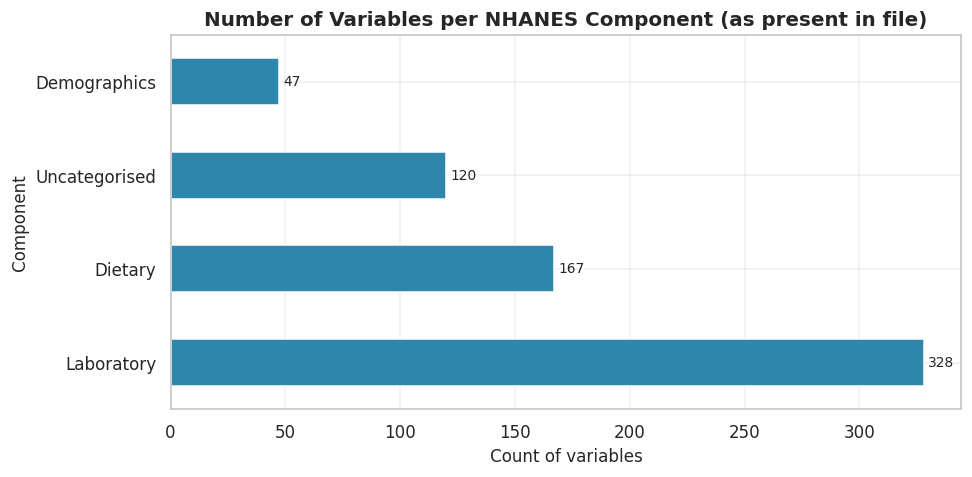

Laboratory       328
Dietary          167
Uncategorised    120
Demographics      47


In [4]:
# ---- Component composition of the columns present in the file ----
# Attribute each column to its NHANES component using the dictionary.
comp_of_col = pd.Series({c: VAR_COMP.get(c, 'Uncategorised') for c in raw.columns})
comp_counts = comp_of_col.value_counts()

fig, ax = plt.subplots(figsize=(9, 4.5))
comp_counts.plot(kind='barh', color=PALETTE[0], ax=ax)
ax.set_title('Number of Variables per NHANES Component (as present in file)')
ax.set_xlabel('Count of variables')
ax.set_ylabel('Component')
for i, v in enumerate(comp_counts.values):
    ax.text(v + 2, i, str(v), va='center', fontsize=9)
plt.tight_layout(); plt.show()

print(comp_counts.to_string())

In [5]:
# ---- Column-level summary table: dtype, #missing, %missing, #unique ----
summary = pd.DataFrame({
    'dtype'      : raw.dtypes.astype(str),
    'n_missing'  : raw.isna().sum(),
    'pct_missing': (raw.isna().mean() * 100).round(1),
    'n_unique'   : raw.nunique(),
})
summary['component'] = [VAR_COMP.get(c, 'Uncategorised') for c in summary.index]
print('First 15 columns (column summary):')
summary.head(15)

First 15 columns (column summary):


,dtype,n_missing,pct_missing,n_unique,component
SEQN,int64,0,0.0,9813,Demographics
SDDSRVYR,int64,0,0.0,1,Demographics
RIDSTATR,int64,0,0.0,1,Demographics
RIAGENDR,int64,0,0.0,2,Demographics
RIDAGEYR,int64,0,0.0,81,Demographics
RIDAGEMN,float64,9171,93.5,25,Demographics
RIDRETH1,int64,0,0.0,5,Demographics
RIDRETH3,int64,0,0.0,6,Demographics
RIDEXMON,int64,0,0.0,2,Demographics
RIDEXAGM,float64,5600,57.1,240,Demographics


In [6]:
# ---- Statistical summary of a clinically important numeric subset ----
# (Describing all 662 columns is unreadable; we spotlight key clinical markers.)
KEY_PREVIEW = ['RIDAGEYR', 'DR1TKCAL', 'DR1TSUGR', 'DR1TSODI',
               'LBXGH', 'LBXSGL', 'LBXTC', 'LBDHDD', 'LBXSUA']
KEY_PREVIEW = [c for c in KEY_PREVIEW if c in raw.columns]
raw[KEY_PREVIEW].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
RIDAGEYR,9813.0,31.63,24.40,0.00,10.00,27.00,52.00,80.0
DR1TKCAL,8531.0,1964.54,984.49,117.00,1309.50,1794.00,2430.00,12108.0
DR1TSUGR,8531.0,109.30,73.34,0.13,61.18,93.98,138.72,1115.5
DR1TSODI,8531.0,3178.13,1818.14,17.00,1975.00,2852.00,4028.50,21399.0
LBXGH,6643.0,5.64,1.00,3.50,5.20,5.40,5.80,17.5
LBXSGL,6553.0,102.29,38.72,49.00,86.00,93.00,104.00,577.0
LBXTC,7624.0,179.53,40.95,69.00,151.00,175.00,204.00,813.0
LBDHDD,7624.0,53.11,15.23,10.00,42.00,51.00,61.00,173.0
LBXSUA,6551.0,5.35,1.40,0.70,4.30,5.20,6.20,13.3


In [7]:
# ---- Duplicate records & unique-patient check ----
dup_full = raw.duplicated().sum()                       # fully identical rows
dup_id   = raw['SEQN'].duplicated().sum()               # repeated patient IDs
print(f'Fully duplicated rows        : {dup_full}')
print(f'Duplicated patient IDs (SEQN): {dup_id}')
print(f'Unique patients (SEQN)       : {raw["SEQN"].nunique():,}')

Fully duplicated rows        : 0
Duplicated patient IDs (SEQN): 0
Unique patients (SEQN)       : 9,813


In [8]:
# ---- Overall missing-value landscape ----
miss_pct = raw.isna().mean() * 100
print(f'Columns with ANY missing values : {(miss_pct > 0).sum():,} of {n_cols:,}')
print(f'Columns >50% missing            : {(miss_pct > 50).sum():,}')
print(f'Columns >90% missing            : {(miss_pct > 90).sum():,}')
print(f'Columns with NO missing values  : {(miss_pct == 0).sum():,}')
print(f'\nAverage missingness across all columns: {miss_pct.mean():.1f}%')

Columns with ANY missing values : 613 of 662
Columns >50% missing            : 334
Columns >90% missing            : 57
Columns with NO missing values  : 49

Average missingness across all columns: 51.2%


# 3 · Data Quality Analysis

**What we are doing:** a systematic audit of data quality *before* modelling.

**Why it is required:** Clustering is **distance-based and unsupervised**, so it has no label to "correct" it — it will faithfully cluster whatever structure exists, *including artefacts*. Garbage columns (constant, near-constant, or 90%-missing) distort distances and silhouette scores. This section quantifies six quality dimensions and visualises each:

1. **Missing values** — where and how much data is absent.
2. **Duplicates** — repeated records that would bias density.
3. **Unique values / constants** — columns carrying zero information.
4. **High-cardinality columns** — IDs/weights that must not be clustered on.
5. **Low-variance features** — features that barely move.
6. **Outliers & distributions** — skew and extremes that dominate Euclidean distance.

**Expected outcome:** a clear, evidence-based short-list of columns to drop and transformations to apply.

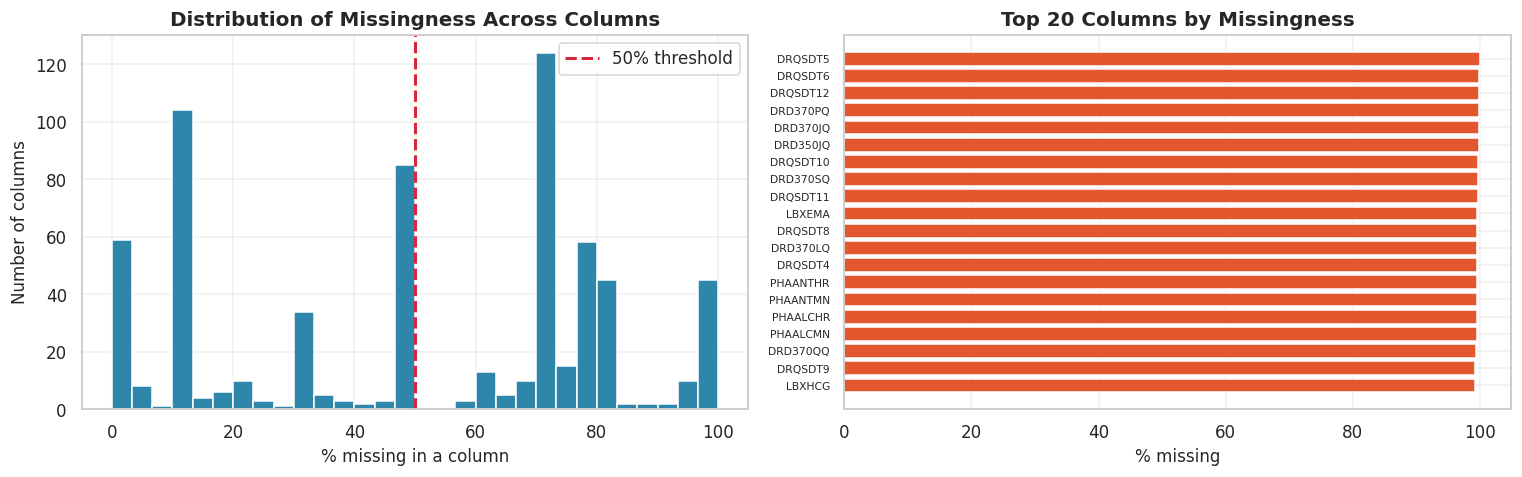

In [9]:
# ---- 3.1 Missing-value distribution across ALL columns ----
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# (a) Histogram of per-column missingness
axes[0].hist(miss_pct.values, bins=30, color=PALETTE[0], edgecolor='white')
axes[0].axvline(50, color=PALETTE[6], ls='--', lw=2, label='50% threshold')
axes[0].set_title('Distribution of Missingness Across Columns')
axes[0].set_xlabel('% missing in a column')
axes[0].set_ylabel('Number of columns')
axes[0].legend()

# (b) Top-20 most-missing columns
top_miss = miss_pct.sort_values(ascending=False).head(20)
axes[1].barh(top_miss.index[::-1], top_miss.values[::-1], color=PALETTE[1])
axes[1].set_title('Top 20 Columns by Missingness')
axes[1].set_xlabel('% missing')
axes[1].tick_params(axis='y', labelsize=7)
plt.tight_layout(); plt.show()

In [10]:
# ---- 3.2 Constant & quasi-constant columns (zero / near-zero information) ----
# A constant column has exactly 1 unique value; quasi-constant ~ 1 value >99% of the time.
nunq = raw.nunique(dropna=True)
constant_cols = nunq[nunq <= 1].index.tolist()

quasi_constant = []
for c in raw.columns:
    vc = raw[c].value_counts(normalize=True, dropna=True)
    if len(vc) > 0 and vc.iloc[0] > 0.99:      # dominant value in >99% of non-null rows
        quasi_constant.append(c)

print(f'Constant columns (<=1 unique value) : {len(constant_cols)}')
print(f'Quasi-constant columns (>99% one val): {len(quasi_constant)}')
print('\nExamples of quasi-constant columns:', quasi_constant[:10])

Constant columns (<=1 unique value) : 23
Quasi-constant columns (>99% one val): 63

Examples of quasi-constant columns: ['SDDSRVYR', 'RIDSTATR', 'FIAPROXY', 'MIAPROXY', 'DRQSDT1', 'DRQSDT2', 'DRQSDT3', 'DRQSDT4', 'DRQSDT6', 'DRQSDT7']


In [11]:
# ---- 3.3 High-cardinality columns (likely IDs, weights, continuous keys) ----
high_card = nunq[nunq > 0.9 * n_rows].index.tolist()
print(f'High-cardinality columns (>90% unique): {high_card}')
print('\nThese are identifiers / survey weights and MUST be excluded from clustering,')
print('because a near-unique value acts like a row index and carries no group structure.')

High-cardinality columns (>90% unique): ['SEQN', 'ar1', 'ar2', 'ar3', 'ar4', 'ar5', 'ar6', 'ar7', 'ar8', 'ar9', 'ar10', 'ar11', 'ar12', 'ar13', 'ar14', 'ar15', 'ar16', 'ar17', 'ar18', 'ar19', 'ar20', 'ar21', 'ar22', 'ar23', 'ar24', 'ar25']

These are identifiers / survey weights and MUST be excluded from clustering,
because a near-unique value acts like a row index and carries no group structure.


In [12]:
# ---- 3.4 Outlier snapshot on key clinical markers (IQR method) ----
def iqr_outlier_pct(series):
    # % of observations beyond 1.5*IQR fences (Tukey's rule).
    s = series.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < lo) | (s > hi)).mean() * 100

out_tbl = pd.DataFrame({
    'variable'   : KEY_PREVIEW,
    'description': [describe_var(c) for c in KEY_PREVIEW],
    'outlier_%'  : [round(iqr_outlier_pct(raw[c]), 1) for c in KEY_PREVIEW],
    'skew'       : [round(raw[c].skew(), 2) for c in KEY_PREVIEW],
})
out_tbl.sort_values('outlier_%', ascending=False)

,variable,description,outlier_%,skew
5,LBXSGL,"Glucose, refrigerated serum (mg/dL)",9.0,5.08
4,LBXGH,Glycohemoglobin (%),8.0,3.94
2,DR1TSUGR,Total sugars (gm),4.1,2.44
3,DR1TSODI,Sodium (mg),3.5,1.65
1,DR1TKCAL,Energy (kcal),3.2,1.71
7,LBDHDD,Direct HDL-Cholesterol (mg/dL),2.2,1.09
6,LBXTC,Total Cholesterol( mg/dL),1.2,1.33
8,LBXSUA,Uric acid (mg/dL),1.2,0.50
0,RIDAGEYR,Age in years of the participant at the time of...,0.0,0.43


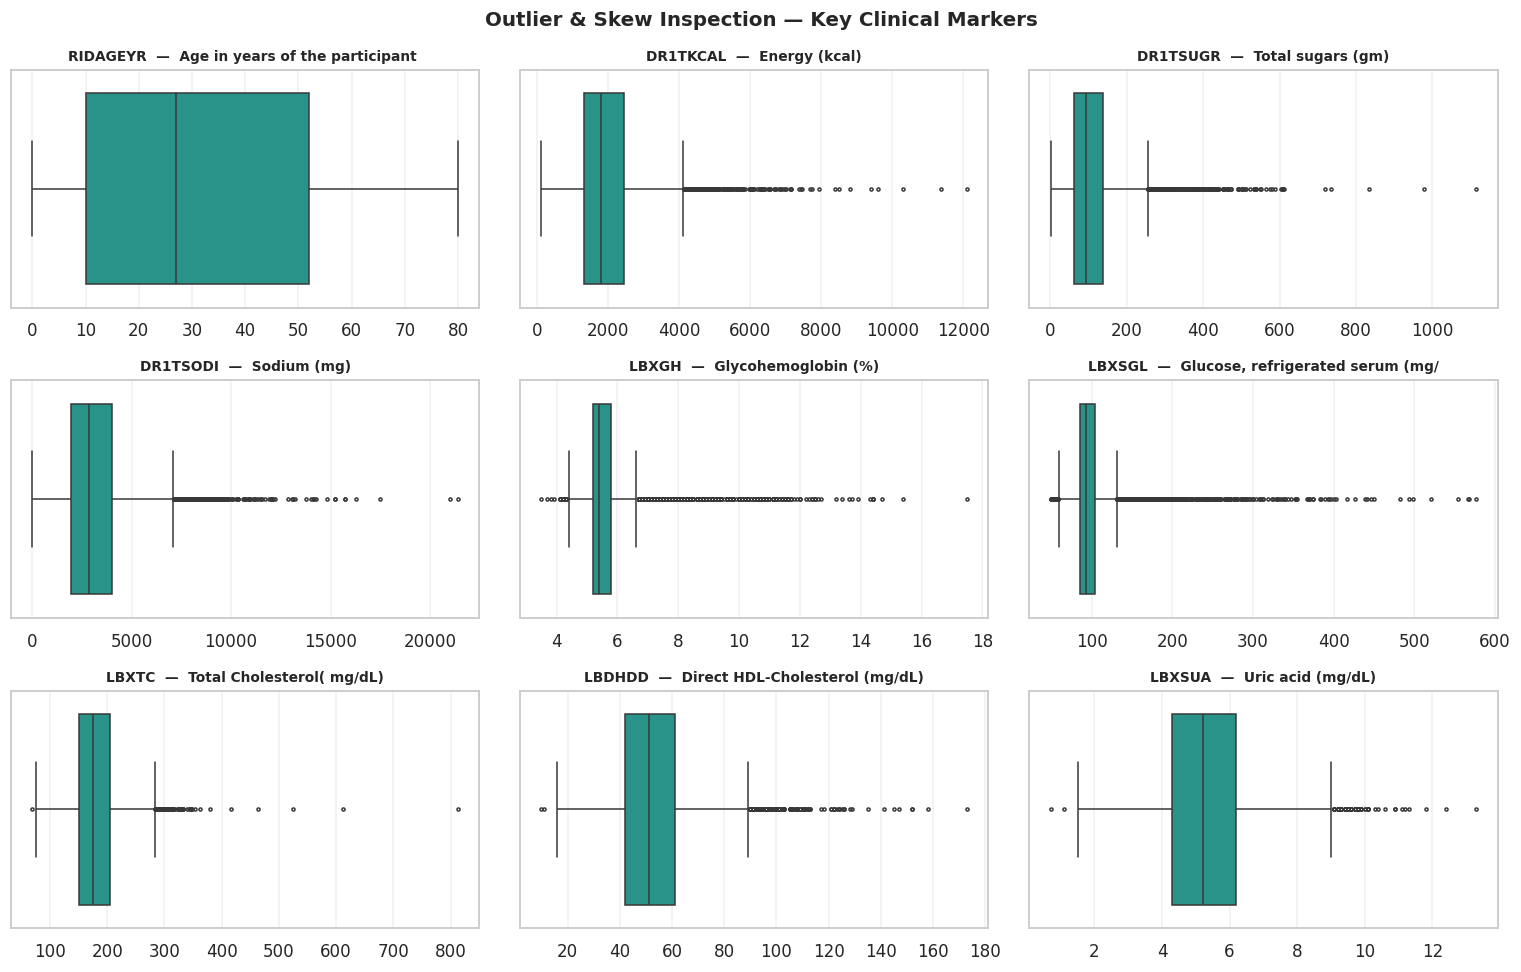

In [13]:
# ---- 3.5 Boxplots exposing outliers & skew in key clinical markers ----
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
for ax, col in zip(axes.ravel(), KEY_PREVIEW):
    sns.boxplot(x=raw[col], ax=ax, color=PALETTE[2], fliersize=2)
    ax.set_title(f'{col}  —  {describe_var(col)[:32]}', fontsize=9)
    ax.set_xlabel('')
# hide any unused axes
for ax in axes.ravel()[len(KEY_PREVIEW):]:
    ax.axis('off')
fig.suptitle('Outlier & Skew Inspection — Key Clinical Markers', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 3.6 Data-Quality Findings

- **Missingness is structural, not random.** NHANES collects different assays on different sub-samples (e.g. fasting-only tests such as LDL, triglycerides, and insulin sit near **68% missing** by design). These will be excluded from the core clustering feature set.
- **Many `LB…` laboratory columns are 90–100% missing** (rare-disease serology, environmental toxicants) — dropped as uninformative for general segmentation.
- **Identifier & survey-weight columns** (`SEQN`, `WT…`, `SDMVPSU`, …) are high-cardinality and must never enter a distance calculation.
- **Right-skew and heavy outliers** dominate dietary and lab markers (e.g. sodium, triglycerides) — motivating **robust handling and scaling** (Sections 5 & 9).

These findings drive every decision in the next section.

In [14]:
# ---- Overall missing-value landscape ----
miss_pct = raw.isna().mean() * 100
print(f'Columns with ANY missing values : {(miss_pct > 0).sum():,} of {n_cols:,}')
print(f'Columns >50% missing            : {(miss_pct > 50).sum():,}')
print(f'Columns >90% missing            : {(miss_pct > 90).sum():,}')
print(f'Columns with NO missing values  : {(miss_pct == 0).sum():,}')
print(f'\nAverage missingness across all columns: {miss_pct.mean():.1f}%')

Columns with ANY missing values : 613 of 662
Columns >50% missing            : 334
Columns >90% missing            : 57
Columns with NO missing values  : 49

Average missingness across all columns: 51.2%


# 4 · Data Cleaning & Feature Curation

**What we are doing:** transforming the raw 662-column survey dump into a clean, clinically coherent **analysis matrix**.

**Why it is required:** Clustering quality is bounded by input quality. Rather than blindly feeding 662 columns (most missing/irrelevant) into K-Means, we **curate a domain-driven feature set** grounded in cardiometabolic medicine, then clean it. Every decision below is justified.

### Cleaning decisions (and their rationale)

| Decision | Rationale |
|---|---|
| **Restrict to adults (age ≥ 18)** | Lab reference ranges, diet needs, and disease risk differ fundamentally for children; mixing them creates artificial age-driven clusters. |
| **Curate ~22 clinical features** | Demographic + dietary + laboratory markers with acceptable coverage and clear clinical meaning (metabolic & cardiovascular axes). |
| **Drop fasting-subsample labs** (LDL, triglycerides, insulin) | ~68% missing — imputing them would fabricate the majority of values. |
| **Drop rows missing >40% of curated features** | Too little signal to place reliably in feature space. |
| **Median-impute the remainder** | Median is robust to the heavy right-skew documented in §3. |
| **Remove one of each highly-correlated pair (\|r\|>0.95)** | Redundant features double-count a dimension and distort Euclidean distance. |
| **Coerce dtypes** | Guarantee every clustering feature is numeric. |

**Expected outcome:** a fully numeric, imputed, de-correlated `df_clean` matrix of adult patients, ready for feature engineering.

In [15]:
# ---- 4.1 Define the curated, clinically meaningful feature set ----
# Keys = NHANES codes; values = human-readable names used throughout the notebook.
FEATURES = {
    # ---------------- Demographic ----------------
    'RIDAGEYR': 'Age',
    'INDFMPIR': 'IncomeToPovertyRatio',
    # ---------------- Dietary (24-hr recall, Day 1) ----------------
    'DR1TKCAL': 'Energy_kcal',
    'DR1TPROT': 'Protein_g',
    'DR1TCARB': 'Carbohydrate_g',
    'DR1TSUGR': 'Sugar_g',
    'DR1TFIBE': 'Fiber_g',
    'DR1TTFAT': 'TotalFat_g',
    'DR1TSFAT': 'SaturatedFat_g',
    'DR1TSODI': 'Sodium_mg',
    # ---------------- Laboratory: metabolic ----------------
    'LBXGH'   : 'HbA1c_pct',        # glycohemoglobin — diabetes marker
    'LBXSGL'  : 'Glucose_mgdl',     # serum glucose
    'LBXTC'   : 'TotalChol_mgdl',   # total cholesterol
    'LBDHDD'  : 'HDL_mgdl',         # "good" cholesterol
    'LBXSUA'  : 'UricAcid_mgdl',    # gout / metabolic marker
    # ---------------- Laboratory: renal / hepatic ----------------
    'LBXSCR'  : 'Creatinine_mgdl',
    'LBXSBU'  : 'BUN_mgdl',
    'LBXSAL'  : 'Albumin_gdl',
    # ---------------- Laboratory: complete blood count ----------------
    'LBXWBCSI': 'WBC_1000cells',
    'LBXHGB'  : 'Hemoglobin_gdl',
    'LBXPLTSI': 'Platelets_1000',
}
# Categorical descriptors kept aside for PROFILING (not core clustering features).
CATEG = {'RIAGENDR': 'Gender', 'RIDRETH1': 'Race', 'DMDEDUC2': 'Education'}

present_feats = [c for c in FEATURES if c in raw.columns]
print(f'Curated numeric features present: {len(present_feats)} / {len(FEATURES)}')
print(f'Categorical descriptors present : {len([c for c in CATEG if c in raw.columns])}')

Curated numeric features present: 21 / 21
Categorical descriptors present : 3


In [16]:
# ---- 4.2 Restrict to the adult cohort (age >= 18) ----
work = raw[raw['RIDAGEYR'] >= 18].copy()
print(f'Adults (age >= 18): {work.shape[0]:,}  (removed {raw.shape[0]-work.shape[0]:,} minors)')

# ---- 4.3 Assemble the working frame: curated features + descriptors + ID ----
keep_cols = ['SEQN'] + present_feats + [c for c in CATEG if c in work.columns]
work = work[keep_cols].copy()

# Rename NHANES codes -> readable names for the numeric features
work = work.rename(columns={**FEATURES, **CATEG})
FEAT_NAMES = [FEATURES[c] for c in present_feats]     # readable clustering-feature names
print(f'Working frame: {work.shape[0]:,} rows x {work.shape[1]} columns')

Adults (age >= 18): 5,924  (removed 3,889 minors)
Working frame: 5,924 rows x 25 columns


In [17]:
# ---- 4.4 Drop rows with excessive missingness (>40% of curated features) ----
thresh = int(0.60 * len(FEAT_NAMES))                  # require >=60% of features present
before = work.shape[0]
work = work.dropna(subset=FEAT_NAMES, thresh=thresh).reset_index(drop=True)
print(f'Rows kept after >=60%-complete filter: {work.shape[0]:,} (removed {before-work.shape[0]:,})')

# ---- 4.5 Median-impute remaining missing values in numeric features ----
imputer = SimpleImputer(strategy='median')
work[FEAT_NAMES] = imputer.fit_transform(work[FEAT_NAMES])
print('Remaining missing values in features after imputation:',
      int(work[FEAT_NAMES].isna().sum().sum()))

Rows kept after >=60%-complete filter: 5,686 (removed 238)
Remaining missing values in features after imputation: 0


In [18]:
# ---- 4.6 Remove highly-correlated redundant features (|r| > 0.95) ----
corr = work[FEAT_NAMES].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if (upper[col] > 0.95).any()]
print('Highly-correlated features removed (|r|>0.95):', to_drop if to_drop else 'None')

FEAT_NAMES = [f for f in FEAT_NAMES if f not in to_drop]
df_clean = work.copy()
print(f'\nFinal clustering feature count: {len(FEAT_NAMES)}')
print(f'Clean adult analysis matrix   : {df_clean.shape[0]:,} patients x {len(FEAT_NAMES)} features')

Highly-correlated features removed (|r|>0.95): None

Final clustering feature count: 21
Clean adult analysis matrix   : 5,686 patients x 21 features
